In [7]:

reviews = [
    "Amazing product! I love it.",
    "Worst quality. Waste of money.",
    "package arrived today."
]

for review in reviews:
    print(review)


Amazing product! I love it.
Worst quality. Waste of money.
package arrived today.


# Task 4: Sentiment Analysis

**In this project, I analysed text comments to understand their sentiment and emotions.
I used Python and NLP techniques to classify comments as positive, negative, or neutral and explored emotions using the NRC lexicon.**

In [8]:
!pip -q install vaderSentiment nrclex

In [9]:
import re, os, json, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from importlib import resources
from scipy import sparse

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             ConfusionMatrixDisplay)


In [10]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [11]:
!wget -O Reviews.csv https://raw.githubusercontent.com/justmarkham/DAT8/master/data/amazon-reviews.csv

--2026-10-09 14:10:12--  https://raw.githubusercontent.com/justmarkham/DAT8/master/data/amazon-reviews.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-10-09 14:10:12 ERROR 404: Not Found.



IMPORT LIBRARY

In [8]:

import pandas as pd

url = "https://raw.githubusercontent.com/Eladjeletabdelmalek/Sentiment-Analysis-Dataset/main/sentiment_data.csv"

df = pd.read_csv(url)

# Keep the columns and score format expected by the existing notebook
df = df.rename(columns={
    "Comment": "Text",
    "Sentiment": "OriginalSentiment"
})

df["Score"] = df["OriginalSentiment"].map({
    0: 1,  # Negative
    1: 3,  # Neutral
    2: 5   # Positive
})

df["Summary"] = df["Text"]

# Remove missing or duplicate comments
df = df.dropna(subset=["Text", "Score"])
df = df.drop_duplicates(subset=["Text"])

# Use a smaller sample to keep Colab training manageable
df = df.sample(n=min(20000, len(df)), random_state=42)

print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nSentiment distribution:")
print(df["OriginalSentiment"].value_counts().sort_index())
display(df.head())


Dataset shape: (20000, 5)

Columns: ['Unnamed: 0', 'Text', 'OriginalSentiment', 'Score', 'Summary']

Sentiment distribution:
OriginalSentiment
0    4515
1    6676
2    8809
Name: count, dtype: int64


,Unnamed: 0,Text,OriginalSentiment,Score,Summary
190868,191646,wonderful video depicting modi,2,5,wonderful video depicting modi
234920,235698,modi fought two seats last time none holy cow ...,0,1,modi fought two seats last time none holy cow ...
194192,194970,till nirav modi jail,0,1,till nirav modi jail
131834,132612,announce proud moments earlier government fail...,2,5,announce proud moments earlier government fail...
88682,89460,full report card modi shocked see india change...,2,5,full report card modi shocked see india change...


In [14]:
# im checking the labels are assignig properly or not

# Create sentiment labels from the Score column

def label_sentiment(score):
    if score <= 2:
        return "Negative"
    elif score == 3:
        return "Neutral"
    else:
        return "Positive"

df["Sentiment"] = df["Score"].apply(label_sentiment)

print("Sentiment counts:")
print(df["Sentiment"].value_counts())

print("\nMissing values:")
print(df[["Text", "Score", "Sentiment"]].isnull().sum())

display(df[["Text", "Score", "Sentiment"]].head())


Sentiment counts:
Sentiment
Positive    8809
Neutral     6676
Negative    4515
Name: count, dtype: int64

Missing values:
Text         0
Score        0
Sentiment    0
dtype: int64


,Text,Score,Sentiment
190868,wonderful video depicting modi,5,Positive
234920,modi fought two seats last time none holy cow ...,1,Negative
194192,till nirav modi jail,1,Negative
131834,announce proud moments earlier government fail...,5,Positive
88682,full report card modi shocked see india change...,5,Positive


In [15]:
# text pre processing

import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text) # remove URLs
    text = re.sub(r"[^a-z\s]", " ", text) # remove unnecessary symbols
    text = re.sub(r"\s+", " ", text).strip()# clean extra spaces
    return text

df["Cleaned_Text"] = df["Text"].apply(clean_text)

display(df[["Text", "Cleaned_Text", "Sentiment"]].head())


,Text,Cleaned_Text,Sentiment
190868,wonderful video depicting modi,wonderful video depicting modi,Positive
234920,modi fought two seats last time none holy cow ...,modi fought two seats last time none holy cow ...,Negative
194192,till nirav modi jail,till nirav modi jail,Negative
131834,announce proud moments earlier government fail...,announce proud moments earlier government fail...,Positive
88682,full report card modi shocked see india change...,full report card modi shocked see india change...,Positive


In [16]:
# dataset spliting

from sklearn.model_selection import train_test_split

X = df["Cleaned_Text"]
y = df["Sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("\nTraining sentiment distribution:")
print(y_train.value_counts())


Training samples: 16000
Testing samples: 4000

Training sentiment distribution:
Sentiment
Positive    7047
Neutral     5341
Negative    3612
Name: count, dtype: int64


In [17]:
#TF-IDF vectorization (Words ko numerical values mein convert karta hai, unki importance ke according)

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training matrix shape:", X_train_tfidf.shape)
print("Testing matrix shape:", X_test_tfidf.shape)
print("Vocabulary size:", len(tfidf.vocabulary_))


Training matrix shape: (16000, 10000)
Testing matrix shape: (4000, 10000)
Vocabulary size: 10000


In [18]:
# the Logistic Regression model training

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

print("Logistic Regression Accuracy:",
      round(accuracy_score(y_test, y_pred_lr) * 100, 2), "%")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 69.8 %

Classification Report:

              precision    recall  f1-score   support

    Negative       0.73      0.47      0.57       903
     Neutral       0.65      0.74      0.69      1335
    Positive       0.72      0.79      0.75      1762

    accuracy                           0.70      4000
   macro avg       0.70      0.66      0.67      4000
weighted avg       0.70      0.70      0.69      4000



In [19]:
# im using another model to get desired o/p
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

svm_model = LinearSVC(
    random_state=42,
    max_iter=2000
)

svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)

print("Linear SVM Accuracy:",
      round(accuracy_score(y_test, y_pred_svm) * 100, 2), "%")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))


Linear SVM Accuracy: 68.65 %

Classification Report:

              precision    recall  f1-score   support

    Negative       0.64      0.56      0.60       903
     Neutral       0.65      0.70      0.67      1335
    Positive       0.73      0.74      0.74      1762

    accuracy                           0.69      4000
   macro avg       0.68      0.67      0.67      4000
weighted avg       0.69      0.69      0.69      4000



In [20]:
# TRAIN NAIVE BAYES

In [21]:

from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import accuracy_score, classification_report

nb_model = ComplementNB(alpha=0.5)

nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

print("Complement Naive Bayes Accuracy:",
      round(accuracy_score(y_test, y_pred_nb) * 100, 2), "%")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_nb))


Complement Naive Bayes Accuracy: 62.9 %

Classification Report:

              precision    recall  f1-score   support

    Negative       0.52      0.65      0.57       903
     Neutral       0.62      0.54      0.58      1335
    Positive       0.71      0.69      0.70      1762

    accuracy                           0.63      4000
   macro avg       0.62      0.62      0.62      4000
weighted avg       0.64      0.63      0.63      4000



In [22]:
# MAKING A COMPARISION TABLE FOR ALL THESE THREE MODEL

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

models = {
    "Logistic Regression": (y_test, y_pred_lr),
    "Linear SVM": (y_test, y_pred_svm),
    "Complement Naive Bayes": (y_test, y_pred_nb)
}

results = []

for name, (actual, predicted) in models.items():
    results.append({
        "Model": name,
        "Accuracy (%)": round(accuracy_score(actual, predicted) * 100, 2),
        "Macro Precision": round(precision_score(actual, predicted, average="macro"), 3),
        "Macro Recall": round(recall_score(actual, predicted, average="macro"), 3),
        "Macro F1-Score": round(f1_score(actual, predicted, average="macro"), 3)
    })

results_df = pd.DataFrame(results).sort_values(
    by="Macro F1-Score", ascending=False
)

display(results_df)


,Model,Accuracy (%),Macro Precision,Macro Recall,Macro F1-Score
0,Logistic Regression,69.80,0.703,0.664,0.672
1,Linear SVM,68.65,0.676,0.667,0.670
2,Complement Naive Bayes,62.90,0.615,0.624,0.616


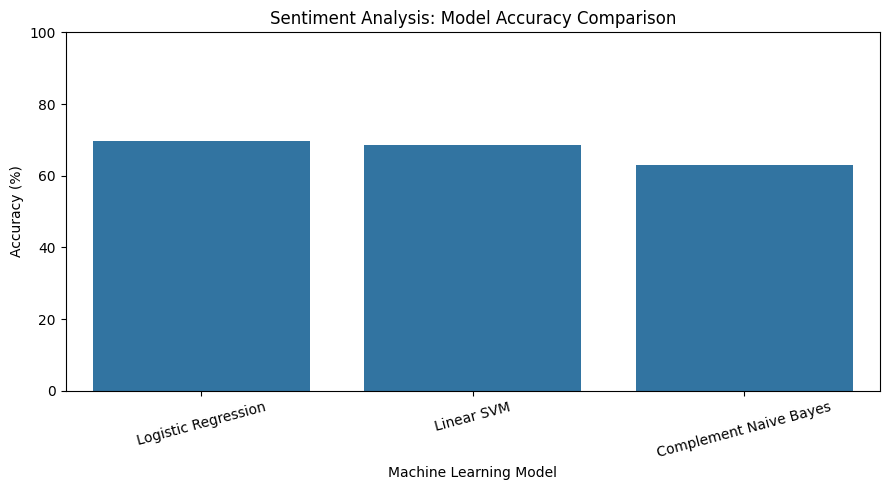

In [23]:

import matplotlib.pyplot as plt
import seaborn as sns

# Compare model accuracy
plt.figure(figsize=(9, 5))
sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy (%)"
)

plt.title("Sentiment Analysis: Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


# Model Comparison and Evaluation

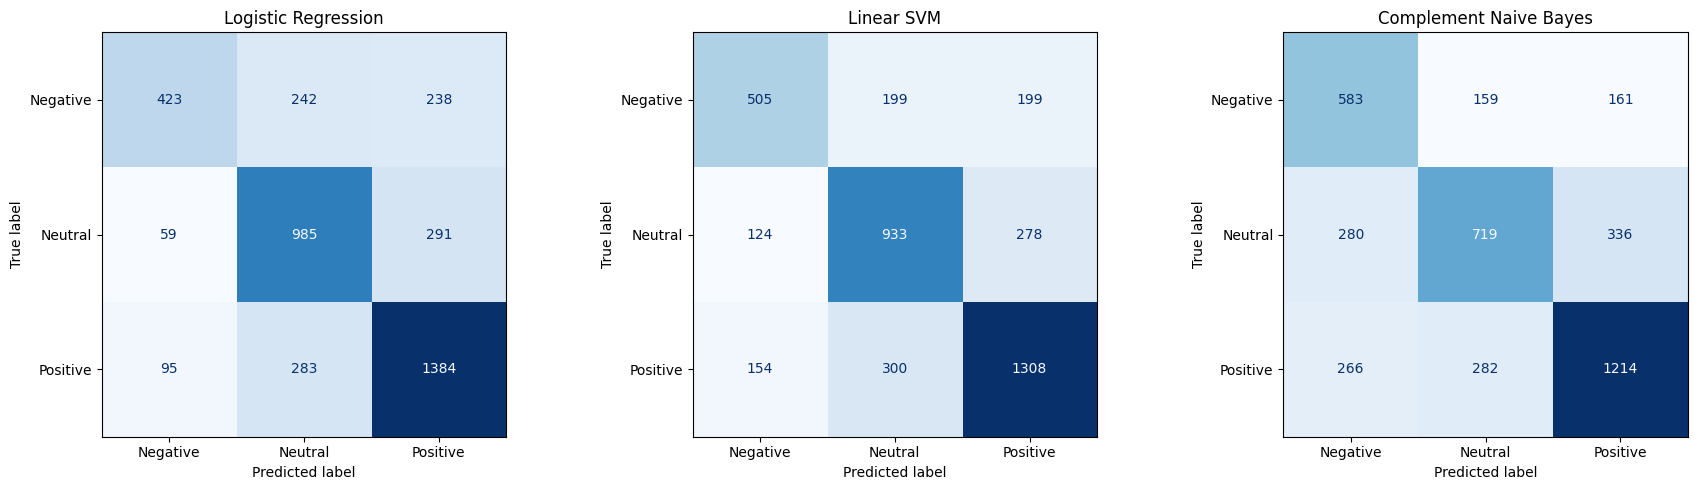

In [24]:
# from this graph i get that with LR model i get more accuracy among all so further for visualization im going to take this LR model's data

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [
    ("Logistic Regression", y_pred_lr),
    ("Linear SVM", y_pred_svm),
    ("Complement Naive Bayes", y_pred_nb)
]

for ax, (name, predictions) in zip(axes, models):
    cm = confusion_matrix(
        y_test,
        predictions,
        labels=["Negative", "Neutral", "Positive"]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Negative", "Neutral", "Positive"]
    )

    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(name)

plt.tight_layout()
plt.show()


# VADER Sentiment Analysis

In [25]:

%pip install vaderSentiment


In [26]:

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.metrics import accuracy_score, classification_report

analyzer = SentimentIntensityAnalyzer()

def vader_sentiment(text):
    compound = analyzer.polarity_scores(str(text))["compound"]

    if compound >= 0.05:
        return "Positive"
    elif compound <= -0.05:
        return "Negative"
    return "Neutral"

y_pred_vader = X_test.apply(vader_sentiment)

print("VADER Accuracy:",
      round(accuracy_score(y_test, y_pred_vader) * 100, 2), "%")

print("\nVADER Classification Report:\n")
print(classification_report(y_test, y_pred_vader))


VADER Accuracy: 56.35 %

VADER Classification Report:

              precision    recall  f1-score   support

    Negative       0.44      0.57      0.50       903
     Neutral       0.60      0.37      0.46      1335
    Positive       0.62      0.70      0.66      1762

    accuracy                           0.56      4000
   macro avg       0.55      0.55      0.54      4000
weighted avg       0.57      0.56      0.56      4000



In [27]:

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score
)
import pandas as pd

all_models = {
    "Logistic Regression": y_pred_lr,
    "Linear SVM": y_pred_svm,
    "Complement Naive Bayes": y_pred_nb,
    "VADER": y_pred_vader
}

comparison = []

for name, predictions in all_models.items():
    comparison.append({
        "Model": name,
        "Accuracy (%)": round(
            accuracy_score(y_test, predictions) * 100, 2
        ),
        "Macro Precision": round(
            precision_score(y_test, predictions, average="macro"), 3
        ),
        "Macro Recall": round(
            recall_score(y_test, predictions, average="macro"), 3
        ),
        "Macro F1": round(
            f1_score(y_test, predictions, average="macro"), 3
        )
    })

comparison_df = pd.DataFrame(comparison).sort_values(
    by="Macro F1", ascending=False
)

display(comparison_df)


,Model,Accuracy (%),Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,69.80,0.703,0.664,0.672
1,Linear SVM,68.65,0.676,0.667,0.670
2,Complement Naive Bayes,62.90,0.615,0.624,0.616
3,VADER,56.35,0.554,0.549,0.539


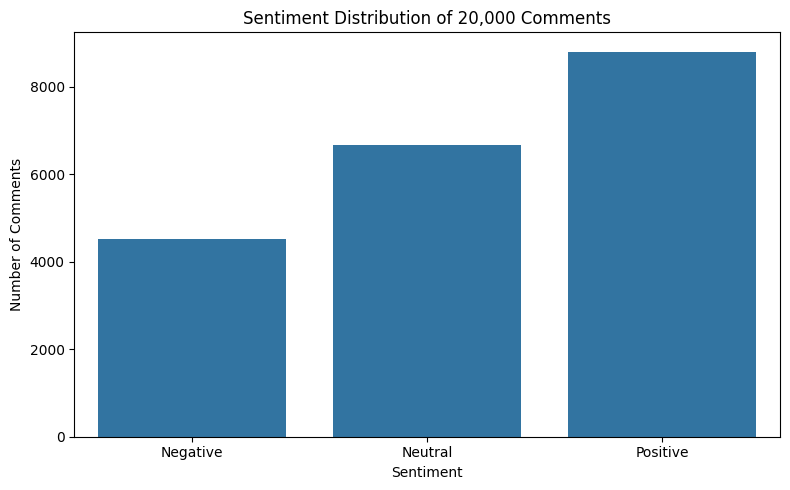

Sentiment
Negative    4515
Neutral     6676
Positive    8809
Name: count, dtype: int64


In [28]:

import matplotlib.pyplot as plt
import seaborn as sns

sentiment_counts = df["Sentiment"].value_counts().reindex(
    ["Negative", "Neutral", "Positive"]
)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=sentiment_counts.index,
    y=sentiment_counts.values
)

plt.title("Sentiment Distribution of 20,000 Comments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")
plt.tight_layout()
plt.show()

print(sentiment_counts)


# Emotion Detection with NRCLex

In [29]:

%pip install NRCLex


In [31]:

# ==========================================
# NRCLex: Emotion Detection
# ==========================================

%pip install -q NRCLex==4.1.0

import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from nrclex import NRCLex

# Check that the dataset and Text column exist
if "Text" not in df.columns:
    raise ValueError("Dataset mein 'Text' column nahi mila.")

# Analyse up to 2,000 comments
sample_texts = df["Text"].dropna().astype(str).sample(
    n=min(2000, df["Text"].notna().sum()),
    random_state=42
)

emotion_counts = Counter()
analyzed_comments = 0

for text in sample_texts:
    try:
        emotion = NRCLex()
        emotion.load_raw_text(text)
        emotion_counts.update(emotion.raw_emotion_scores)
        analyzed_comments += 1
    except Exception as e:
        print("Skipped a comment due to:", e)

# Display results
print("Comments analysed:", analyzed_comments)
print("\nEmotion counts:")

if emotion_counts:
    emotion_df = pd.DataFrame(
        emotion_counts.items(),
        columns=["Emotion", "Count"]
    ).sort_values("Count", ascending=False)

    print(emotion_df.to_string(index=False))

    # Plot emotion distribution
    plt.figure(figsize=(10, 5))
    plt.bar(emotion_df["Emotion"], emotion_df["Count"])
    plt.title("Emotion Distribution in Text Dataset")
    plt.xlabel("Emotion")
    plt.ylabel("Word-level Emotion Matches")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No emotion matches found. Check the dataset and lexicon.")


Streaming output truncated to the last 5000 lines.

    python -m textblob.download_corpora

or use the NLTK downloader to download the missing data: http://nltk.org/data.html
If this doesn't fix the problem, file an issue at https://github.com/sloria/TextBlob/issues.

Skipped a comment due to: 
Looks like you are missing some required data for this feature.

To download the necessary data, simply run

    python -m textblob.download_corpora

or use the NLTK downloader to download the missing data: http://nltk.org/data.html
If this doesn't fix the problem, file an issue at https://github.com/sloria/TextBlob/issues.

Skipped a comment due to: 
Looks like you are missing some required data for this feature.

To download the necessary data, simply run

    python -m textblob.download_corpora

or use the NLTK downloader to download the missing data: http://nltk.org/data.html
If this doesn't fix the problem, file an issue at https://github.com/sloria/TextBlob/issues.

Skipped a comment due 

In [33]:

print("Dataset shape:", df.shape)
print("Column names:", df.columns.tolist())
print(df.head(3).to_string())


Dataset shape: (241145, 3)
Column names: ['Unnamed: 0', 'Comment', 'Sentiment']
   Unnamed: 0                                                                                                                                                                                                                                  Comment  Sentiment
0           0  lets forget apple pay required brand new iphone order use significant portion apples user base wasnt able use even wanted successive iphone incorporated technology older iphones replaced number people could use technology increased          1
1           1                                                                                                                        nz retailers don’t even contactless credit card machines like paywave support apple pay don’t like high fees come          0
2           2                                                                                                                       forever acknow

Dataset shape: (241145, 3)
Text column: Comment

Comments analysed: 2000

Emotion counts:
     Emotion  Count
    positive   2752
       trust   1996
    negative   1858
anticipation   1458
         joy   1164
        fear    961
       anger    954
     sadness    858
     disgust    635
    surprise    632


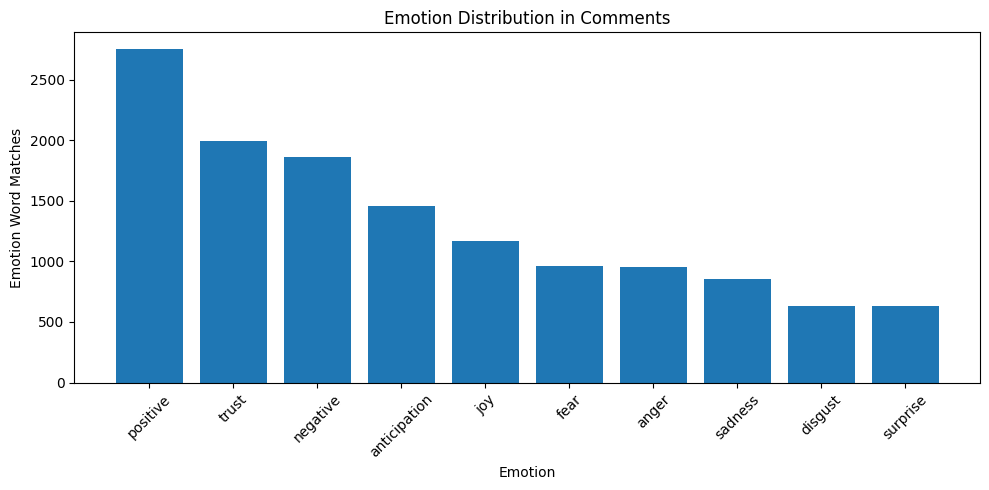

In [34]:

# ==========================================
# NRCLex Emotion Detection
# ==========================================

%pip install -q NRCLex==4.1.0

import nltk
nltk.download("brown", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("averaged_perceptron_tagger_eng", quiet=True)
nltk.download("conll2000", quiet=True)
nltk.download("movie_reviews", quiet=True)

import subprocess
subprocess.run(
    ["python", "-m", "textblob.download_corpora"],
    capture_output=True,
    text=True
)

import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from nrclex import NRCLex

# Load the dataset
url = "https://raw.githubusercontent.com/Eladjeletabdelmalek/Sentiment-Analysis-Dataset/main/sentiment_data.csv"
df = pd.read_csv(url)

print("Dataset shape:", df.shape)
print("Text column: Comment")

# Select up to 2,000 comments
sample_texts = df["Comment"].dropna().astype(str).sample(
    n=min(2000, df["Comment"].notna().sum()),
    random_state=42
)

emotion_counts = Counter()
analyzed_comments = 0

# Run emotion analysis
for text in sample_texts:
    try:
        emotion = NRCLex()
        emotion.load_raw_text(text)
        emotion_counts.update(emotion.raw_emotion_scores)
        analyzed_comments += 1
    except Exception:
        continue

print("\nComments analysed:", analyzed_comments)

# Display results and chart
if emotion_counts:
    emotion_df = pd.DataFrame(
        emotion_counts.items(),
        columns=["Emotion", "Count"]
    ).sort_values("Count", ascending=False)

    print("\nEmotion counts:")
    print(emotion_df.to_string(index=False))

    plt.figure(figsize=(10, 5))
    plt.bar(emotion_df["Emotion"], emotion_df["Count"])
    plt.title("Emotion Distribution in Comments")
    plt.xlabel("Emotion")
    plt.ylabel("Emotion Word Matches")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No emotion matches found. TextBlob resources may still be missing.")


# so we have now two things
Sentiment classification: Positive, Neutral, Negative — tumhare pehle ke models LR, Linear SVM, Complement Naive Bayes and VADER.

Emotion detection: NRC lexicon ke through 2,000 comments mein positive, trust, negative, joy, fear jaise emotion-word matches.

In [1]:
# SENTIMENT vs EMOTION ANALYSIS
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from nrclex import NRCLex

# 1. Load the dataset if df is not already available
if "df" not in globals():
    url = "https://raw.githubusercontent.com/Eladjeletabdelmalek/Sentiment-Analysis-Dataset/main/sentiment_data.csv"
    df = pd.read_csv(url)

# 2. Select the same sample of comments
sample = df[["Comment", "Sentiment"]].dropna().sample(
    n=min(2000, len(df[["Comment", "Sentiment"]].dropna())),
    random_state=42
).copy()

# 3. Detect emotions for each comment
emotion_names = [
    "trust", "anticipation", "joy", "fear",
    "anger", "sadness", "disgust", "surprise"
]

emotion_results = []

for text in sample["Comment"].astype(str):
    try:
        analyzer = NRCLex()
        analyzer.load_raw_text(text)
        scores = analyzer.raw_emotion_scores

        emotion_results.append({
            emotion: scores.get(emotion, 0)
            for emotion in emotion_names
        })
    except Exception:
        emotion_results.append({
            emotion: 0 for emotion in emotion_names
        })

emotion_df = pd.DataFrame(emotion_results, index=sample.index)
combined = pd.concat([sample, emotion_df], axis=1)


In [2]:
# 4. Compare sentiment labels with emotion-word matches
print("Comments analysed:", len(combined))
print("\nSentiment distribution:")
print(combined["Sentiment"].value_counts())

print("\nEmotion-word matches by sentiment:")
emotion_by_sentiment = combined.groupby("Sentiment")[
    emotion_names
].sum()
print(emotion_by_sentiment)

Comments analysed: 2000

Sentiment distribution:
Sentiment
2    846
1    687
0    467
Name: count, dtype: int64

Emotion-word matches by sentiment:
           trust  anticipation  joy  fear  anger  sadness  disgust  surprise
Sentiment                                                                   
0            450           315  223   330    316      310      252       137
1            432           311  214   218    241      205      142       150
2           1114           832  727   413    397      343      241       345


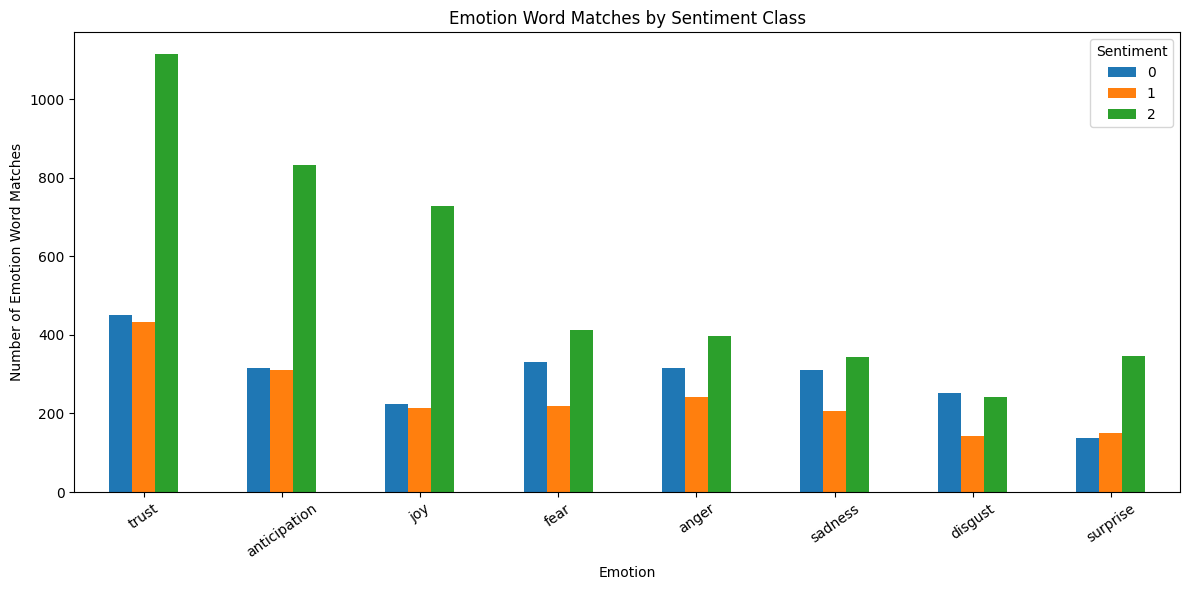

In [3]:

# 5. Visualize emotion patterns for each sentiment class
ax = emotion_by_sentiment.T.plot(
    kind="bar",
    figsize=(12, 6)
)
ax.set_title("Emotion Word Matches by Sentiment Class")
ax.set_xlabel("Emotion")
ax.set_ylabel("Number of Emotion Word Matches")
plt.xticks(rotation=35)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

In [6]:

# 6. Find the most frequent emotion words in each sentiment class
print("\nMost frequent emotion-word category per sentiment:")
for sentiment, row in emotion_by_sentiment.iterrows():
    print(f"{sentiment}: {row.idxmax()} ({int(row.max())} matches)")

print("definitive emotions or the number of comments expressing them.")



Most frequent emotion-word category per sentiment:
0: trust (450 matches)
1: trust (432 matches)
2: trust (1114 matches)
definitive emotions or the number of comments expressing them.


**WHAT THIS RESULT TELLS ME** :
from 2000 analysed comments

i have found

Positive:846 — 42.3%

Neutral:687 — 34.35%

Negative:467 — 23.35%

# **### Conclusion**

I analysed **2,000** comments for sentiment and emotions. Around 42.3% were positive, **34.35%** neutral, and **23.35%** negative. Trust was the most common emotion, followed by anticipation and joy in positive comments. Overall, the results show that comments can express different emotions even when they have the same sentiment.